In [1]:
import numpy as np
import os

In [2]:
# Parameter grids -> 4 x 3 x 4 x 3 = 144 trajectories
Ye_MIN, Ye_MAX, N_YE = 0.03, 0.3, 4
Ye_values = np.linspace(Ye_MIN, Ye_MAX, N_YE)

R0 = 50.0                                     # km, common intercept for R(t)
velocities = np.array([4.5e4])  # km/s, slopes for R(t)

density_inits = np.array([ 1e13])  # g/cm^3, target density(t=0)

T_inits = np.array([10.0])  # GK, target T9(t=0)

SOURCE_FILE = "Data/Original_files/NSM_Trajectories/nsm_representative.dat"
OUTPUT_DIR = "Data/Trajectories"

In [3]:
# Reference time sampling, T9(t) and density(t) curves used as the baseline
# that gets shifted to hit each target initial value. R(t) is replaced
# entirely by a linear function, so the original R column is not needed.
data = np.genfromtxt(SOURCE_FILE, comments="#")
time, T9_ref, density_ref = data[:, 0], data[:, 1], data[:, 2]

with open(SOURCE_FILE) as f:
    header = f.readline().rstrip("\n")

print(f"Loaded {len(time)} time points from {SOURCE_FILE}")

Loaded 216 time points from Data/Original_files/NSM_Trajectories/nsm_representative.dat


In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

log_rows = []
idx = 0
for Ye in Ye_values:
    for v in velocities:
        R = R0 + v * time
        for dens_init in density_inits:
            # Multiplicative scaling: keeps density > 0 everywhere and
            # preserves the reference decay shape, unlike an additive
            # shift (which goes negative whenever dens_init < density_ref[0]).
            density = density_ref * (dens_init / density_ref[0])
            for T_init in T_inits:
                T9 = T9_ref * (T_init / T9_ref[0])

                idx += 1
                fname = f"traj{idx:04d}.dat"
                outpath = os.path.join(OUTPUT_DIR, fname)
                with open(outpath, "w") as f:
                    f.write(header + "\n\n")
                    for t, T9_, dens, r in zip(time, T9, density, R):
                        f.write(f"{t:.4e} {T9_:.4e} {dens:.4e} {r:.4e} {Ye:.5f}\n")

                log_rows.append((fname, Ye, v, R0, dens_init, T_init))

print(f"Wrote {idx} trajectory files to {OUTPUT_DIR}")

Wrote 4 trajectory files to Data/Trajectories


In [5]:
# Lookup table so the 4 parameters behind each file stay traceable
log_path = os.path.join(OUTPUT_DIR, "trajectories_index.csv")
with open(log_path, "w") as f:
    f.write("file,Ye,R_velocity_km_s,R0_km,density_init_g_cm3,T9_init_GK\n")
    for row in log_rows:
        f.write("{},{:.5f},{:.3e},{:.1f},{:.3e},{:.2f}\n".format(*row))

print(f"Wrote index file to {log_path}")

Wrote index file to Data/Trajectories/trajectories_index.csv


In [6]:
import matplotlib.pyplot as plt

# Fixed categorical order (blue, orange, aqua, yellow) -> same slot always
# means the same "which parameter value", never re-cycled across plots.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
GRID_COLOR = "#e1e0d9"

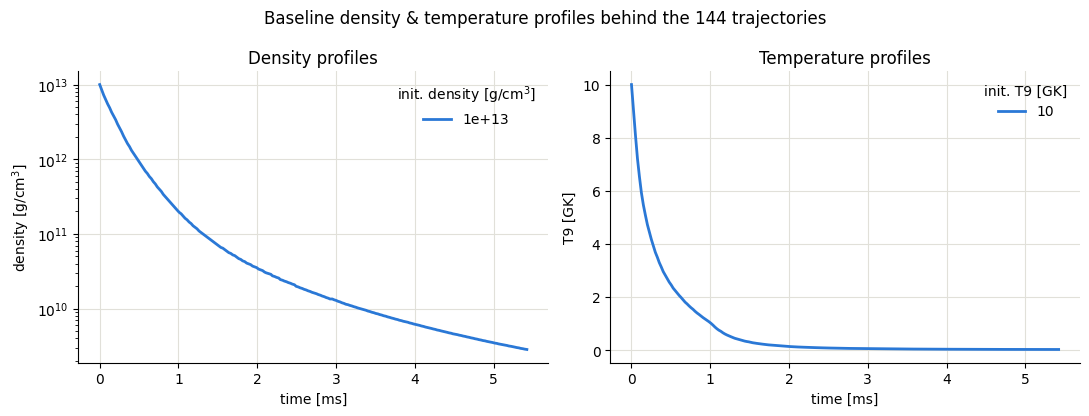

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
for color, dens_init in zip(CATEGORICAL, density_inits):
    density = density_ref * (dens_init / density_ref[0])
    ax.plot(time * 1e3, density, color=color, lw=2, label=f"{dens_init:.0e}")
ax.set_yscale("log")
ax.set_xlabel("time [ms]")
ax.set_ylabel(r"density [g/cm$^3$]")
ax.set_title("Density profiles")
ax.grid(True, color=GRID_COLOR, lw=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, title="init. density [g/cm$^3$]")

ax = axes[1]
for color, T_init in zip(CATEGORICAL, T_inits):
    T9 = T9_ref * (T_init / T9_ref[0])
    ax.plot(time * 1e3, T9, color=color, lw=2, label=f"{T_init:.0f}")
ax.set_xlabel("time [ms]")
ax.set_ylabel("T9 [GK]")
ax.set_title("Temperature profiles")
ax.grid(True, color=GRID_COLOR, lw=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, title="init. T9 [GK]")

fig.suptitle("Baseline density & temperature profiles behind the 144 trajectories")
fig.tight_layout()
plt.show()